In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from tqdm import tqdm
from pathlib import Path

from pulse_analysis import read_root_file, format_root_data

# Load data

In [2]:
max_events = 10000
file_path = Path("/disk/gfs_atp/lhoetz/marmotx/data_20260507/XDet_GXe_p1581mbar_noPumpNoGetter_KrContaminationPossible_ANDtrigger_800V")
file_name = Path("XDet_GXe_p1581mbar_noPumpNoGetter_KrContaminationPossible_ANDtrigger_800V_Module_0_0.root")

full_path = file_path / file_name
_ar = read_root_file(full_path, max_events=max_events)
data = format_root_data(_ar, n_baseline_samples=50)

Raw file keys: ['t1;28', 't1;27']
Number of events: 10000
Sample length: 2500
Data shape: (10000, 2, 2500)


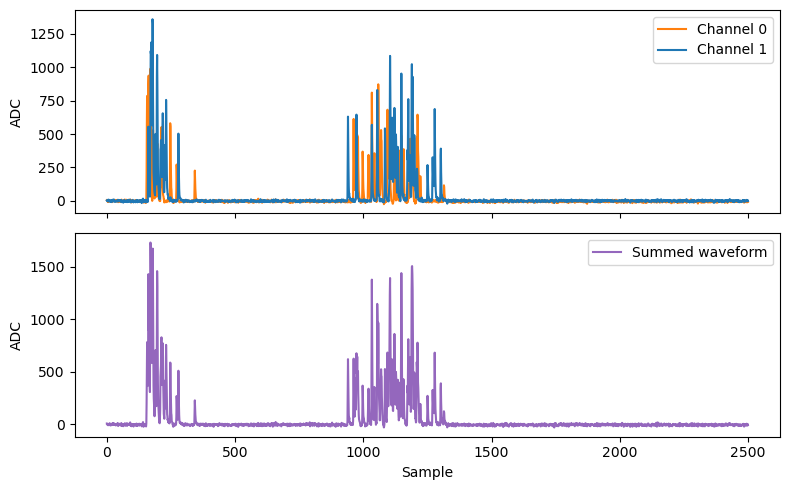

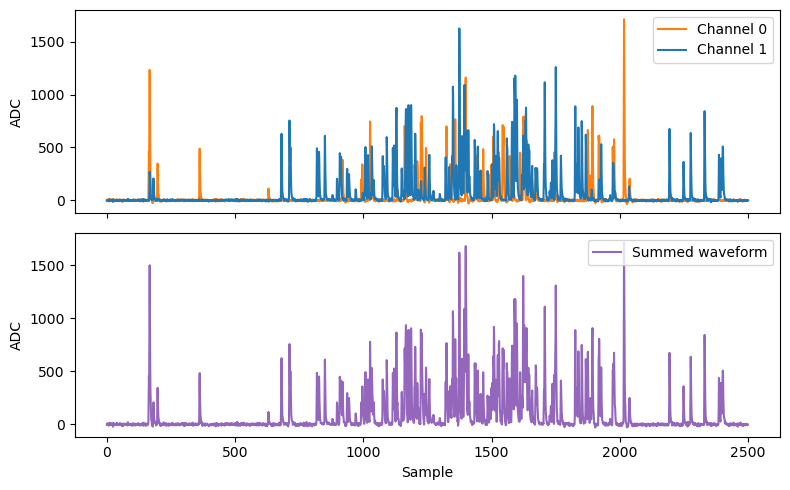

In [8]:
n_pulses_plot = 2

for i in range(n_pulses_plot):
    fig, axs = plt.subplots(2, 1, figsize=(8, 5), sharex=True, sharey=False)

    event_id = data["event_index"][i]

    ch0_wf = data["wfs"][i, 0, :]
    ch1_wf = data["wfs"][i, 1, :]
    summed_wf = ch0_wf + ch1_wf

    axs[0].plot(ch0_wf, label="Channel 0", color="tab:orange")
    axs[0].plot(ch1_wf, label="Channel 1", color="tab:blue")
    axs[1].plot(summed_wf, label="Summed waveform", color="tab:purple")

    axs[1].set_xlabel("Sample")
    axs[0].set_ylabel("ADC")
    axs[1].set_ylabel("ADC")

    axs[0].legend()
    axs[1].legend()

    # Remove space between plots
    fig.subplots_adjust(hspace=0)

    plt.tight_layout()
    plt.show()

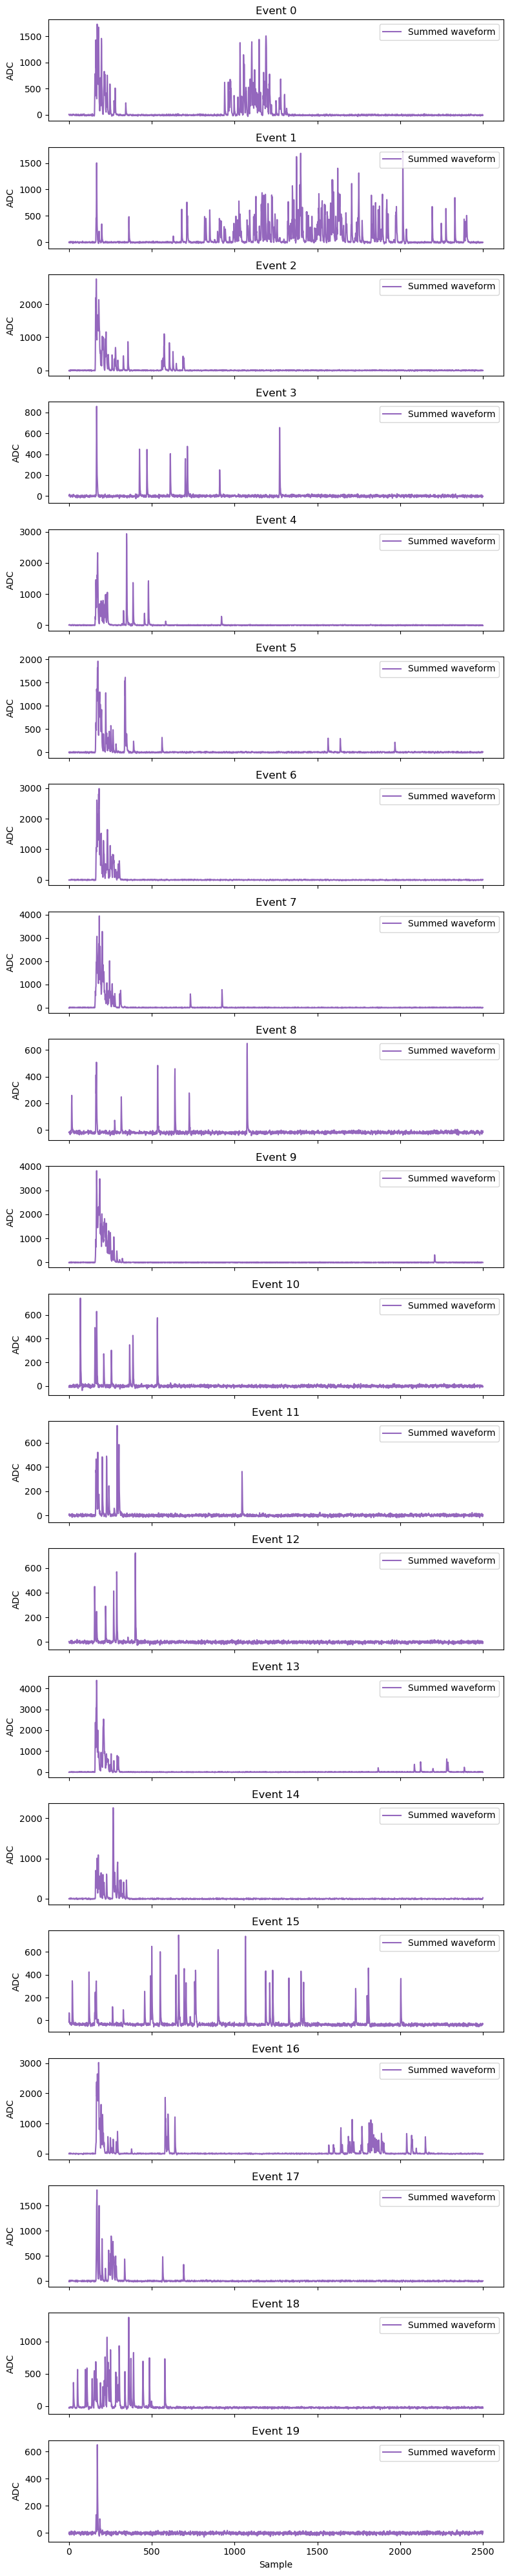

In [9]:
n_pulses_plot = 20

fig, axs = plt.subplots(n_pulses_plot, 1, figsize=(8, 2 * n_pulses_plot), sharex=True)

if n_pulses_plot == 1:
    axs = [axs]

for i in range(n_pulses_plot):
    event_id = data["event_index"][i]

    ch0_wf = data["wfs"][i, 0, :]
    ch1_wf = data["wfs"][i, 1, :]
    summed_wf = ch0_wf + ch1_wf

    ax = axs[i]
    ax.plot(summed_wf, color="tab:purple", label="Summed waveform")
    ax.set_ylabel("ADC")
    ax.set_title(f"Event {event_id}")
    ax.legend(loc="upper right")

axs[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()